# Session 6 — Understanding Neural Network Forward Propagation

This practice notebook explores how values move through neural-network layers.

Topics:
- A one-layer forward pass
- A two-layer network
- Inspecting intermediate activations
- Batch processing with a deeper network

The examples use new input values, weights, naming, presentation, and experiments.

## 1. One-Layer Forward Pass

We begin with a small network that transforms an input vector into two output values.

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

features = np.array([0.3, 0.9, 0.4, 0.7])

weights = np.array([
    [0.15, 0.55],
    [0.65, 0.25],
    [0.35, 0.80],
    [0.45, 0.20]
])

bias = np.array([0.10, -0.05])

linear_result = features @ weights + bias
prediction = sigmoid(linear_result)

print("Features:", features)
print("Linear combination:", np.round(linear_result, 4))
print("Sigmoid output:", np.round(prediction, 4))

Features: [0.3 0.9 0.4 0.7]
Linear combination: [1.185 0.8  ]
Sigmoid output: [0.7658 0.69  ]


The calculation can be viewed as:

**input → weighted sum + bias → activation**

The sigmoid then converts each final value into a number between 0 and 1.

## 2. Two-Layer Network

Here the first layer uses ReLU and the final layer uses sigmoid.

In [2]:
def relu(x):
    return np.maximum(0, x)

sample = np.array([0.25, 0.60, 0.85, 0.40])

layer1_weights = np.array([
    [0.4, 0.2, 0.7],
    [0.8, 0.3, 0.1],
    [0.2, 0.9, 0.5],
    [0.6, 0.4, 0.8]
])

layer1_bias = np.array([-0.10, 0.05, 0.15])

layer2_weights = np.array([
    [0.7, 0.3],
    [0.5, 0.8],
    [0.2, 0.6]
])

layer2_bias = np.array([0.05, 0.10])

hidden_linear = sample @ layer1_weights + layer1_bias
hidden_values = relu(hidden_linear)

final_linear = hidden_values @ layer2_weights + layer2_bias
final_values = sigmoid(final_linear)

print("Input:", sample)
print("\nBefore ReLU:", np.round(hidden_linear, 4))
print("Hidden activations:", np.round(hidden_values, 4))
print("\nBefore sigmoid:", np.round(final_linear, 4))
print("Final output:", np.round(final_values, 4))

Input: [0.25 0.6  0.85 0.4 ]

Before ReLU: [0.89  1.205 1.13 ]
Hidden activations: [0.89  1.205 1.13 ]

Before sigmoid: [1.5015 2.009 ]
Final output: [0.8178 0.8817]


### Interpretation

The hidden layer creates intermediate features. ReLU removes negative activations, and those transformed values are then passed into the output layer.

## 3. Inspecting Activations with a Plot

Instead of displaying the layers in separate subplots, this experiment compares their values using grouped bars.

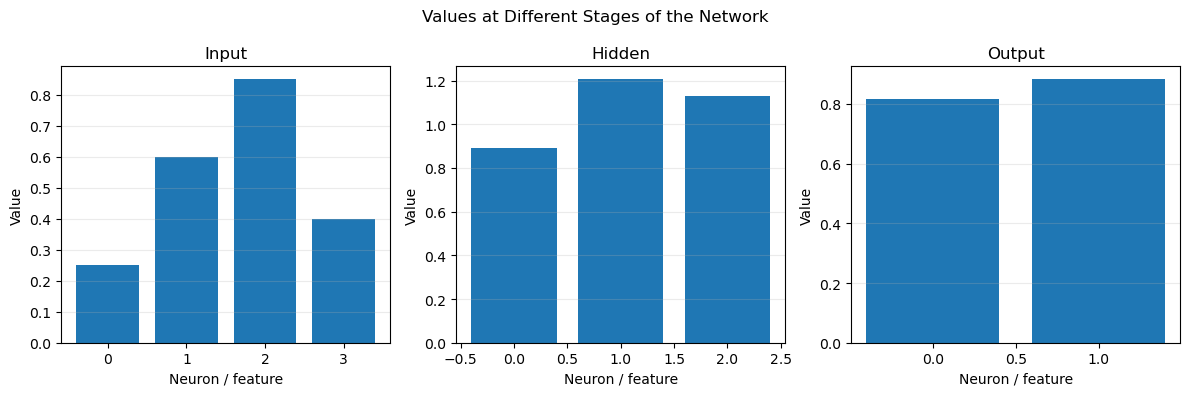

In [3]:
import matplotlib.pyplot as plt

layer_names = ["Input", "Hidden", "Output"]
layer_values = [
    sample,
    hidden_values,
    final_values
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, title, values in zip(axes, layer_names, layer_values):
    axis.bar(np.arange(len(values)), values)
    axis.set_title(title)
    axis.set_xlabel("Neuron / feature")
    axis.set_ylabel("Value")
    axis.grid(axis="y", alpha=0.25)

fig.suptitle("Values at Different Stages of the Network")
plt.tight_layout()
plt.show()

**What to observe:** the hidden layer may contain zeros because ReLU suppresses negative values. The output layer is compressed into the 0–1 range by sigmoid.

## 4. Forward Propagation for a Batch

Neural networks normally process more than one input. Here we use four observations at once.

In [4]:
batch = np.array([
    [0.15, 0.35, 0.75, 0.55],
    [0.80, 0.20, 0.45, 0.90],
    [0.50, 0.65, 0.30, 0.25],
    [0.95, 0.40, 0.60, 0.10]
])

rng = np.random.default_rng(17)

weights_a = rng.uniform(-0.4, 0.7, size=(4, 5))
weights_b = rng.uniform(-0.3, 0.8, size=(5, 2))

bias_a = rng.uniform(-0.1, 0.2, size=5)
bias_b = rng.uniform(-0.1, 0.2, size=2)

hidden_batch = relu(batch @ weights_a + bias_a)
batch_predictions = sigmoid(hidden_batch @ weights_b + bias_b)

for row_number, (features, prediction) in enumerate(
    zip(batch, batch_predictions), start=1
):
    print(f"Sample {row_number}")
    print("  Input :", np.round(features, 3))
    print("  Output:", np.round(prediction, 4))
    print()

Sample 1
  Input : [0.15 0.35 0.75 0.55]
  Output: [0.6047 0.5817]

Sample 2
  Input : [0.8  0.2  0.45 0.9 ]
  Output: [0.6208 0.5921]

Sample 3
  Input : [0.5  0.65 0.3  0.25]
  Output: [0.6105 0.5768]

Sample 4
  Input : [0.95 0.4  0.6  0.1 ]
  Output: [0.5873 0.5799]



## 5. Quick Experiment

Change one input value and see how the final prediction changes.

In [5]:
modified_batch = batch.copy()

# Change only the first feature of the first observation.
modified_batch[0, 0] = 0.95

original_prediction = sigmoid(
    relu(batch @ weights_a + bias_a) @ weights_b + bias_b
)

modified_prediction = sigmoid(
    relu(modified_batch @ weights_a + bias_a) @ weights_b + bias_b
)

print("Original first output :", np.round(original_prediction[0], 4))
print("Modified first output :", np.round(modified_prediction[0], 4))
print("Difference            :", np.round(
    modified_prediction[0] - original_prediction[0], 4
))

Original first output : [0.6047 0.5817]
Modified first output : [0.6106 0.5888]
Difference            : [0.006  0.0071]


## Summary

- A **forward pass** calculates layer outputs from input values.
- Weights determine how strongly each input contributes.
- Bias terms shift the weighted sums.
- **ReLU** is useful for hidden-layer transformations and can produce zero activations.
- **Sigmoid** maps output values into the 0–1 interval.
- Matrix multiplication allows the same operations to be performed efficiently on a batch.
- Small changes to an input can propagate through every subsequent layer and change the final output.